In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

### 1. Preprocessing (10 points)
##### • Load the dataset from WineData.xlsx
##### • Encode type as a numeric variable (red = 1, white = 0).
##### • Create a binary target variable:
##### • target_good = 1 if quality >= 6, else 0.
##### • Split data into training and testing sets (80/20).
##### • Standardize the features using StandardScal

In [3]:
data = pd.read_excel('WineData.xlsx') # load in excel file
data.head() # show first 5 rows

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
# preprocessing
data_copy = data.copy() # copy original dataset into new variable 
data_copy['type_encode'] = (data_copy['type']=='red').astype(int) 
# new column in data_copy that changes value type 
# i.e. categorical info to be int

In [5]:
data_copy.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_encode
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [6]:
data_copy['target_good'] = (data_copy['quality']>=6).astype(int) 
# new column 'target_good' in data_copy dataset that only considers values in 'quality' column 
# 6 and over, so if >= 6 then 1, else 0 

data_copy.head() # showing proof, have to look on far right side for new info

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_encode,target_good
0,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,0
1,red,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,red,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,0
3,red,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1,1
4,red,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,0


In [7]:
data_copy.columns.tolist() # list all columns in dataset

X = [ 'fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'type_encode',] # features variable 

# feature_cols = [c for c in data_copy.columns c not in ['']]
# variable where logic checks if columns in data_copy are the following 
# then it would list the remaining columns
# not working for me but this code is easier

y = ['target_good'] # target varialbe

X, y = data_copy[X], data_copy[y]
# without this, the variables X and y are just a list of column names
# that have 0 reference to the actual dataset so that's what's being done here!!!

In [8]:
from sklearn.model_selection import train_test_split # train_test_split package

X_train, X_test, y_train, y_test = train_test_split( # standard set up for training
    X,
    y,
    test_size=0.2,
    random_state=11032025) # the train/test split

X_train.shape, X_test.shape, y_train.shape, y_test.shape # shape i.e. dimensions of both X and ys

((5197, 12), (1300, 12), (5197, 1), (1300, 1))

### 2. Support Vector Machine (SVM) Classification (20 points)
##### • Train an SVM classifier (RBF kernel) to predict target_good
##### • Evaluate model performance using:
##### o Accuracy
##### o Confusion matrix
##### o Classification report
##### • Discuss model accuracy and insights

In [9]:
from sklearn.svm import SVC # support vector machine package package with support vector classifier
from sklearn.pipeline import Pipeline # Pipeline package
from sklearn.preprocessing import StandardScaler # StandardScaler package

svm_classifier = Pipeline( # standard way set up for Pipeline
    steps=[
        ('scaler',StandardScaler()),
        ('svc',SVC())
    ]
)
svm_classifier.fit(X_train,y_train) # adjusting X and y training sets to the SVM model

/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC())])

In [10]:
y_pred_svm = svm_classifier.predict(X_test) # i forgot how this works
from sklearn.metrics import accuracy_score # accuracy score package (how accurate the model is but what is accuracy model itself then?)
acc_svm = accuracy_score(y_test,y_pred_svm) # variable to hold accuracy rate of this
print("SVM accuracy",acc_svm) # printing SVM accuracy

SVM accuracy 0.7646153846153846


In [11]:
from sklearn.metrics import classification_report,confusion_matrix # import packages

In [12]:
print(classification_report(y_test,y_pred_svm)) # provides classification report of variables but not sure why those particularly

              precision    recall  f1-score   support

           0       0.70      0.65      0.68       486
           1       0.80      0.83      0.82       814

    accuracy                           0.76      1300
   macro avg       0.75      0.74      0.75      1300
weighted avg       0.76      0.76      0.76      1300



In [13]:
print(confusion_matrix(y_test,y_pred_svm)) # confusion matrix of the same info above

[[318 168]
 [138 676]]


**Discussion on model accuracy and insights** 

Accuracy score is 76.4%, an average score in comparison to standard 90% and above being good scores. Classification report: precision reflects the number of found positive predictions which falls in 70-80% range. Recall rates fall within 60-80% range, a pretty poor score (at least from what I remember having a standard score to be within 90% range, but this can mean that some positive predictions are being overlooked. Confusion matrix looks decent too because both true positives (TP) and true negatives (TN) are larger than any false positives nor false negatives. 

### 3. Logistic Regression (20 + 10 points)
• Train a logistic regression model on the same task.

• Evaluate accuracy, confusion matrix, and classification report.

• Bonus: Identify which features most strongly influence wine quality using the learned coefficients. (10 points)

• Discuss model accuracy and insights

In [14]:
# logistic regression
from sklearn.linear_model import LogisticRegression # import LR package
LR_classifier = Pipeline( # assuming this is a standard way to set it up
    steps=[
        ('scaler',StandardScaler()),
        ('logreg',LogisticRegression())
    ]
)
LR_classifier.fit(X_train,y_train) # fit X and ys to LR model

/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('scaler', StandardScaler()), ('logreg', LogisticRegression())])

In [15]:
y_pred_LR = LR_classifier.predict(X_test) # same thing
acc_LR = accuracy_score(y_test,y_pred_LR) # var for LR accuracy score 
print("Log Reg Accuracy: ",acc_LR) # print LR accuracy score

Log Reg Accuracy:  0.75


In [16]:
print(classification_report(y_test,y_pred_LR)) # LR classification report
print(confusion_matrix(y_test,y_pred_LR)) # LR confusion matrix

              precision    recall  f1-score   support

           0       0.68      0.62      0.65       486
           1       0.79      0.83      0.81       814

    accuracy                           0.75      1300
   macro avg       0.73      0.72      0.73      1300
weighted avg       0.75      0.75      0.75      1300

[[302 184]
 [141 673]]


**Discussion on model accuracy and insights** 

Accuracy score is 75% even, an average score in comparison to standard 90% and above being good scores. Classification report: precision reflects the number of found positive predictions which falls in 70-80% range, a bit higher than SVM's. Like SVM, recall rates fall within 60-80% range, a pretty poor score (at least from what I remember having a standard score to be within 90% range, but this can mean that some positive predictions are being overlooked. Confusion matrix has similar output to SVM too because both true positives (TP) and true negatives (TN) are larger than any false positives nor false negatives. 

### 4. K-Means Clustering (30 points)
##### • Apply K-Means clustering (k = 3) to the standardized features.
##### • Visualize clusters using PCA (2D projection).
##### • Compare cluster assignments with the actual wine type or quality—do natural clusters align with known labels?
##### • Discuss cluster structure and separability

In [17]:
from sklearn.neighbors import KNeighborsClassifier # KNNClassifier package
from sklearn.decomposition import PCA # RE INITIATION

knn = KNeighborsClassifier(n_neighbors=3) # initialization
knn.fit(X_train,y_train) # fitting X and y values to KNN model
pred = knn.predict(X_test) # prediction
knn # print

pca = PCA(0.95) # model with PCA with 95% variance

X_train_pca = pca.fit_transform(X_train) # fitting X train
X_test_pca = pca.transform(X_test) # fitting X test

pca_knn = KNeighborsClassifier(n_neighbors = 5) # initialization
pca_knn.fit(X_train_pca, y_train) # fitting X and y values to KNN model AND YOU NEED THE SPACE
pca_pred = pca_knn.predict(X_test_pca) # prediction
pca_knn # print

print("PCA accuracy score: ",accuracy_score(y_test,pca_pred)) # pca accuracy score

PCA accuracy score:  0.6146153846153846


/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/sydneeangus/Library/Python/3.9/lib/python/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


**Compare cluster assignments with the actual wine type or quality—do natural clusters align with known labels?**

I don't know and I'm not sure where this is in reference to.

**Discussion on cluster structure and separability** 

Accuracy score is 61.4%, much much lower and thus a poor accuracy score overall. 

### 5. Hierarchical Clustering (20 points)
##### • Perform hierarchical clustering using Ward’s method.
##### • For clarity, use a random subset of 200 samples.
##### • Plot a dendrogram and discuss:
##### • How clusters form at different distance thresholds.
##### • Differences from K-Means clustering.

In [117]:
# hierarchical clustering
# dendogram
from scipy.cluster.hierarchy import linkage,dendrogram # improt clustering respective to linkage+dendrogram

max_n=200 # max num to 200
scaler_HC=StandardScaler() # var to initiate StandardScaler
X_std=scaler_HC.fit_transform(X) # not sure what this is
subset=min(max_n,X_std.shape[0]) # not sure what this is 
rng=np.random.RandomState(11032025) # assuming a random number in bounds 0-11032025
idx=rng.choice(X_std.shape[0],size=subset) # also not sure what this is

In [120]:
Z=linkage(X_std[idx],method='ward') # don't know 

AttributeError: module 'matplotlib' has no attribute 'title'

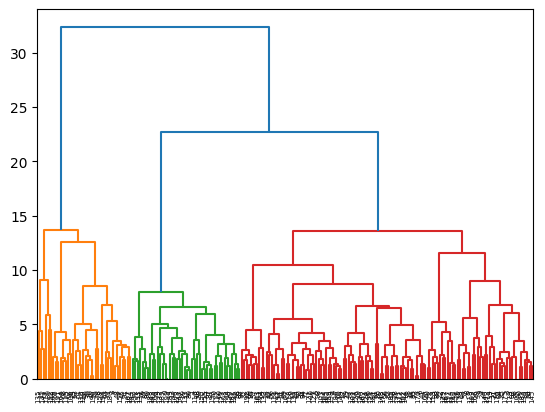

In [125]:
#plt.figure()
dendrogram(Z) # dendrogram shown
plt.title("dendrogram")
plt.tight_layout()
#plt.show()

AttributeError: module 'matplotlib' has no attribute 'tight_layout'

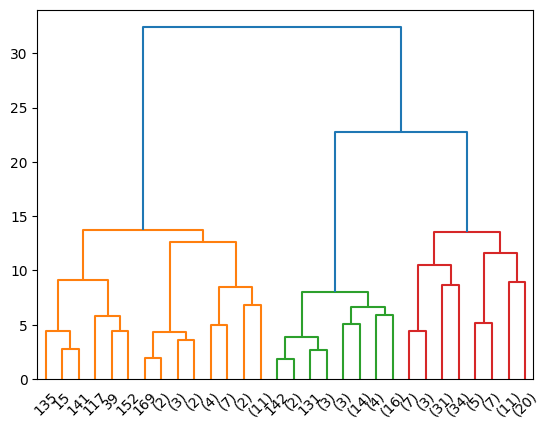

In [128]:
#plt.figure()
dendrogram(
    Z,
    truncate_mode='level',
    p=4
)
plt.tight_layout()

**How clusters form at different distance thresholds.**

Based on how close the clusters are to one another.

**Discussion on differences from K-Means clustering.**

KMeans clustering always requires to have a set number of clusters, whereas hierarchical clustering does not. In addition, hierarchical clustering 